In [1]:
import torch
import numpy as np
import pandas as pd
import networkx as nx

from utils import (load_graph_from_txt, compute_shuffled_tree_energy)
from pathlib import Path
from vis import Plotter
import matplotlib.pyplot as plt

from utils import load_graph_from_txt, compute_neighbor_loss_over_records

## shuffled tree

Grid - #nodi: 15 #archi: 14
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '1' has only 1 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '7' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token '1' has only 1 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token '7' has only 4 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token '1' has only 3 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token '3' has only 1 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '1' has only 4 occurrences in [0:100] (requested 5)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '3' has only 1 occurrences in [0:100] (requested 5)
  [ctx=2000, win_len=120, local=[0:120)] Warning: token '15' has only 2 occurrences in [0:120] (requested 5)
  [ctx=2000, win_

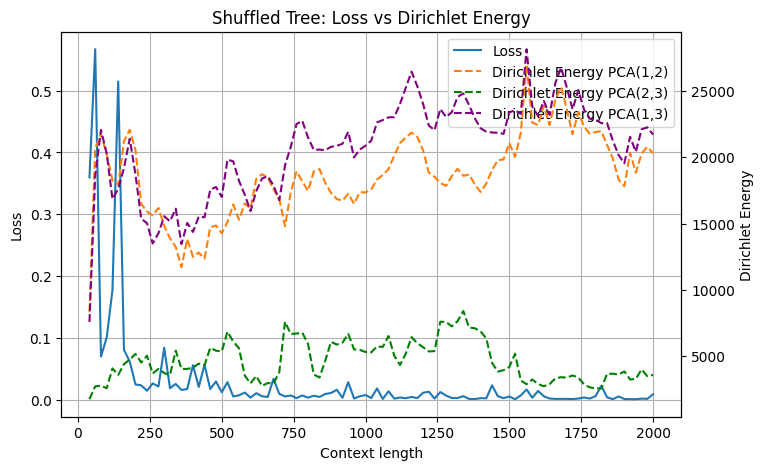

In [2]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "shuffled_tree_numbers"
structure_name = "bin_tree"

GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

PROB_DIR    = Path(f"../embeddings/new/{grid_folder}")
logit_file = PROB_DIR / f"final_topk_pairAB_step10_bin_tree_numbers_shuffled_one_rw_2000.pt"

EMB_DIR    = Path(f"../embeddings/reps&probs32/{grid_folder}")
emb_filename = "reprs_bin_tree_numbers_shuffled_one_rw_2000_line000000_layer32.pt"

# compute loss

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, PROB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())


# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()


# COMPUTE SHUFFLED TREE ENERGY

ctx = 2000
WIN = 20
K = 5
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=PCA_K,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
)

shuffled_tree_energy23 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
)

shuffled_tree_energy13 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=0,
    pc2=2,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
energy13_y = np.asarray(shuffled_tree_energy13[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
line4 = ax2.plot(
    energy_x_tokens,
    energy13_y,
    "--",
    color="purple",
    label="Dirichlet Energy PCA(1,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title("Shuffled Tree: Loss vs Dirichlet Energy")
plt.show()

## in-order tree

Grid - #nodi: 15 #archi: 14
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 2 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '12' has only 1 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token '15' has only 4 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=60, local=[0:60)] Warning: token '12' has only 1 occurrences in [0:60] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token '12' has only 3 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=80, local=[0:80)] Warning: token '8' has only 1 occurrences in [0:80] (requested 5)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '12' has only 4 occurrences in [0:100] (requested 5)
  [ctx=2000, win_len=100, local=[0:100)] Warning: token '8' has only 1 occurrences in [0:100] (requested 5)
  [ctx=2000, win_len=120, local=[0:120)] Warning: token '4' has only 1 occurrences in [0:120] (requested 5)
  [ctx=2000,

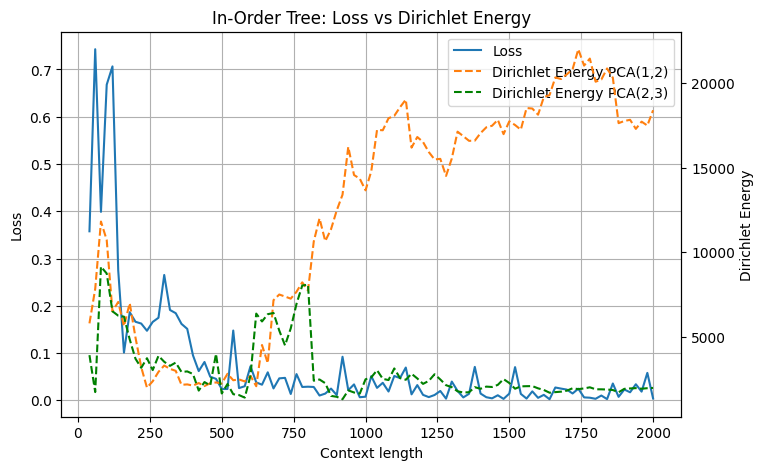

In [3]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "tree_numbers"
structure_name = "bin_tree"

GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

PROB_DIR    = Path(f"../embeddings/new/{grid_folder}")
logit_file = PROB_DIR / f"final_topk_pairAB_step10_bin_tree_one_rw_2000.pt"

EMB_DIR    = Path(f"../embeddings/reps&probs32/{grid_folder}")
emb_filename = "reprs_bin_tree_one_rw_2000_line000000_layer32.pt"

# compute loss

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, PROB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())


# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()


# COMPUTE SHUFFLED TREE ENERGY

ctx = 2000
WIN = 20
K = 5
PCA_K = 2
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=PCA_K,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
)

shuffled_tree_energy23 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
)

loss_x_words = shuffled_tree_numbers_loss[:, 0].astype(float)
loss_y = shuffled_tree_numbers_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(shuffled_tree_energy[0], dtype=float)
energy_y = np.asarray(shuffled_tree_energy[1], dtype=float)
energy23_y = np.asarray(shuffled_tree_energy23[1], dtype=float)
# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title("In-Order Tree: Loss vs Dirichlet Energy")
plt.show()

# Circle

## ordered

Grid - #nodi: 15 #archi: 15
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '15' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '13' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '14' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '1' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '2' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '9' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '10' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '15' has only 1 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '13' has only 1 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=

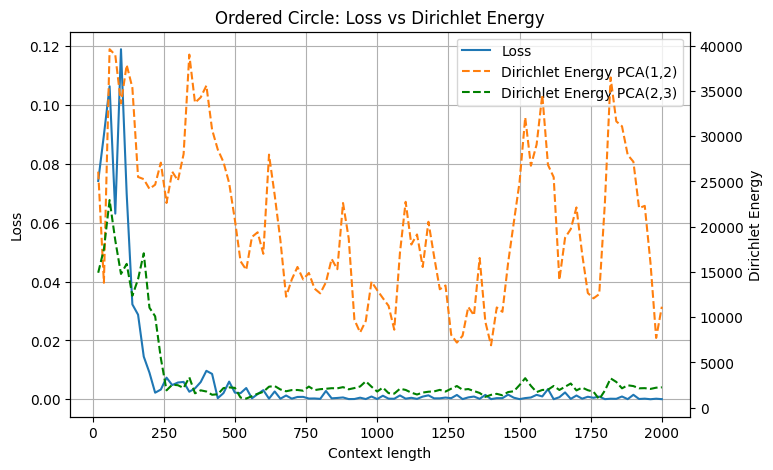

In [4]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "circle_numbers"
structure_name = "circle_numbers"

GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/circle_structure.txt")

PROB_DIR    = Path(f"../embeddings/new/{grid_folder}")
logit_file = PROB_DIR / f"final_topk_pairAB_step10_{structure_name}_one_rw_2000.pt"

EMB_DIR    = Path(f"../embeddings/reps&probs32/{grid_folder}")
emb_filename = f"reprs_{structure_name}_one_rw_2000_line000000_layer32.pt"

# compute loss

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, PROB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="cycle")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())


# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

ordered_circle_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE SHUFFLED TREE ENERGY

ctx = 2000
WIN = 20
K = 5
PCA_K = 2
MIN_NODES = PCA_K + 1

ordered_circle_energy = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=PCA_K,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="cycle",
)

ordered_circle_energy23 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="cycle",
)

ordered_circle_energy34 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=2,
    pc2=3,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="cycle",
)

loss_x_words = ordered_circle_loss[:, 0].astype(float)
loss_y = ordered_circle_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(ordered_circle_energy23[0], dtype=float)
energy_y = np.asarray(ordered_circle_energy[1], dtype=float)
energy23_y = np.asarray(ordered_circle_energy23[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title("Ordered Circle: Loss vs Dirichlet Energy")
plt.show()

## shuffled

Grid - #nodi: 15 #archi: 15
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '11' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '14' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '1' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '2' has only 2 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '4' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '9' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=20, local=[0:20)] Warning: token '10' has only 1 occurrences in [0:20] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '11' has only 1 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=40, local=[0:40)] Warning: token '14' has only 1 occurrences in [0:40] (requested 5)
  [ctx=2000, win_len=4

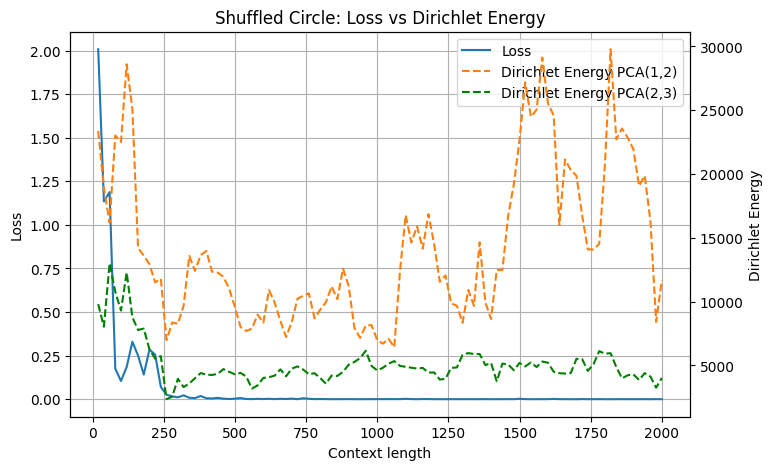

In [5]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "shuffled_circle_numbers"
structure_name = "shuffled_circle_numbers"
name= "circle_numbers_shuffled"

GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/circle_structure.txt")

PROB_DIR    = Path(f"../embeddings/new/{grid_folder}")
logit_file = PROB_DIR / f"final_topk_pairAB_step10_{name}_one_rw_2000.pt"

EMB_DIR    = Path(f"../embeddings/reps&probs32/{grid_folder}")
emb_filename = f"reprs_{name}_one_rw_2000_line000000_layer32.pt"

# compute loss

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, PROB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="cycle")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())


# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

ordered_circle_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE SHUFFLED TREE ENERGY

ctx = 2000
WIN = 20
K = 5
PCA_K = 2
MIN_NODES = PCA_K + 1

ordered_circle_energy = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=PCA_K,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="cycle",
)

ordered_circle_energy23 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="cycle",
)

ordered_circle_energy34 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=2,
    pc2=3,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="cycle",
)

loss_x_words = ordered_circle_loss[:, 0].astype(float)
loss_y = ordered_circle_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(ordered_circle_energy23[0], dtype=float)
energy_y = np.asarray(ordered_circle_energy[1], dtype=float)
energy23_y = np.asarray(ordered_circle_energy23[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title("Shuffled Circle: Loss vs Dirichlet Energy")
plt.show()

# GRID

## ordered

In [ ]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "grid_numbers"
structure_name = "grid_numbers"
name= "grid_numbers"

GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/grid_structure.txt")

PROB_DIR    = Path(f"../embeddings/new/{grid_folder}")
logit_file = PROB_DIR / f"final_topk_pairAB_step10_{name}_one_rw_2000.pt"

EMB_DIR    = Path(f"../embeddings/reps&probs32/{grid_folder}")
emb_filename = f"reprs_{name}_one_rw_2000_line000000_layer32.pt"

# compute loss

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, PROB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())


# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

ordered_circle_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE SHUFFLED TREE ENERGY

ctx = 2000
WIN = 20
K = 5
PCA_K = 2
MIN_NODES = PCA_K + 1

ordered_circle_energy = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=PCA_K,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="grid",
)

ordered_circle_energy23 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="grid",
)


loss_x_words = ordered_circle_loss[:, 0].astype(float)
loss_y = ordered_circle_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(ordered_circle_energy23[0], dtype=float)
energy_y = np.asarray(ordered_circle_energy[1], dtype=float)
energy23_y = np.asarray(ordered_circle_energy23[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title("Grid Ordered: Loss vs Dirichlet Energy")
plt.show()

## shuffled

In [ ]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "shuffled_grid_numbers"
name= "grid_numbers_shuffled"

GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/grid_structure.txt")

PROB_DIR    = Path(f"../embeddings/new/{grid_folder}")
logit_file = PROB_DIR / f"final_topk_pairAB_step10_{name}_one_rw_2000.pt"

EMB_DIR    = Path(f"../embeddings/reps&probs32/{grid_folder}")
emb_filename = f"reprs_{name}_one_rw_2000_line000000_layer32.pt"

# compute loss

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, PROB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())


# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

ordered_circle_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE SHUFFLED TREE ENERGY

ctx = 2000
WIN = 20
K = 5
PCA_K = 2
MIN_NODES = PCA_K + 1

ordered_circle_energy = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=PCA_K,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="grid",
)

ordered_circle_energy23 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="grid",
)

ordered_circle_energy34 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=2,
    pc2=3,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="grid",
)

loss_x_words = ordered_circle_loss[:, 0].astype(float)
loss_y = ordered_circle_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(ordered_circle_energy23[0], dtype=float)
energy_y = np.asarray(ordered_circle_energy[1], dtype=float)
energy23_y = np.asarray(ordered_circle_energy23[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"Grid Shuffled: Loss vs Dirichlet Energy")
plt.show()

# DAYS

## tree

In [ ]:
VOCAB_PATH = Path("../data/days_tkid_map.txt")

grid_folder = "tree_days"
name= "bin_tree_days"

GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/bin_tree_structure.txt")

PROB_DIR    = Path(f"../embeddings/new/{grid_folder}")
logit_file = PROB_DIR / f"final_topk_pairAB_step10_{name}_dataset_2000.pt"

EMB_DIR    = Path(f"../embeddings/reps&probs32/{grid_folder}")
emb_filename = f"reprs_{name}_dataset_2000_line000000_layer32.pt"

# compute loss

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, PROB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())


# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

ordered_circle_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE SHUFFLED TREE ENERGY

ctx = 2000
WIN = 20
K = 5
PCA_K = 2
MIN_NODES = PCA_K + 1

ordered_circle_energy = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=PCA_K,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="tree",
)

ordered_circle_energy23 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="tree",
)

loss_x_words = ordered_circle_loss[:, 0].astype(float)
loss_y = ordered_circle_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(ordered_circle_energy23[0], dtype=float)
energy_y = np.asarray(ordered_circle_energy[1], dtype=float)
energy23_y = np.asarray(ordered_circle_energy23[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"Tree Days: Loss vs Dirichlet Energy")
plt.show()

## circle ordered

In [ ]:
VOCAB_PATH = Path("../data/days_tkid_map.txt")

grid_folder = "circle_days"
name= "circle_days"

GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/circle_structure.txt")

PROB_DIR    = Path(f"../embeddings/new/{grid_folder}")
logit_file = PROB_DIR / f"final_topk_pairAB_step10_{name}_one_rw_2000.pt"

EMB_DIR    = Path(f"../embeddings/reps&probs32/{grid_folder}")
emb_filename = f"reprs_{name}_one_rw_2000_line000000_layer32.pt"

# compute loss

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, PROB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="cycle")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())


# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

ordered_circle_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE SHUFFLED TREE ENERGY

ctx = 2000
WIN = 20
K = 5
PCA_K = 2
MIN_NODES = PCA_K + 1

ordered_circle_energy = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=PCA_K,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="cycle",
)

ordered_circle_energy23 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="cycle",
)

loss_x_words = ordered_circle_loss[:, 0].astype(float)
loss_y = ordered_circle_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(ordered_circle_energy23[0], dtype=float)
energy_y = np.asarray(ordered_circle_energy[1], dtype=float)
energy23_y = np.asarray(ordered_circle_energy23[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"Circle Ordered Days: Loss vs Dirichlet Energy")
plt.show()

## circle shuffled

In [ ]:
VOCAB_PATH = Path("../data/days_tkid_map.txt")

grid_folder = "shuffled_circle_days"
name= "circle_days_shuffled"

GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/circle_structure.txt")

PROB_DIR    = Path(f"../embeddings/new/{grid_folder}")
logit_file = PROB_DIR / f"final_topk_pairAB_step10_{name}_one_rw_2000.pt"

EMB_DIR    = Path(f"../embeddings/reps&probs32/{grid_folder}")
emb_filename = f"reprs_{name}_one_rw_2000_line000000_layer32.pt"

# compute loss

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, PROB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="cycle")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())


# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

ordered_circle_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

# COMPUTE SHUFFLED TREE ENERGY

ctx = 2000
WIN = 20
K = 5
PCA_K = 2
MIN_NODES = PCA_K + 1

ordered_circle_energy = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=PCA_K,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="cycle",
)

ordered_circle_energy23 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="cycle",
)

loss_x_words = ordered_circle_loss[:, 0].astype(float)
loss_y = ordered_circle_loss[:, 1].astype(float)

energy_x_tokens = np.asarray(ordered_circle_energy23[0], dtype=float)
energy_y = np.asarray(ordered_circle_energy[1], dtype=float)
energy23_y = np.asarray(ordered_circle_energy23[1], dtype=float)

# riscala asse x della loss sulla scala token
loss_x_tokens = loss_x_words * (energy_x_tokens.max() / loss_x_words.max())

# interpola loss sugli stessi x della energy
loss_y_interp_on_energy_x = np.interp(energy_x_tokens, loss_x_tokens, loss_y)

fig, ax1 = plt.subplots(figsize=(8, 5))

energy_color = "tab:orange"
loss_color = "tab:blue"

# asse y sinistro: loss
line1 = ax1.plot(
    energy_x_tokens,
    loss_y_interp_on_energy_x,
    label="Loss",
    color=loss_color
)
ax1.set_xlabel("Context length")
ax1.set_ylabel("Loss")
ax1.grid()

# asse y destro: energy
ax2 = ax1.twinx()
line2 = ax2.plot(
    energy_x_tokens,
    energy_y,
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
line3 = ax2.plot(
    energy_x_tokens,
    energy23_y,
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
ax2.set_ylabel("Dirichlet Energy")

# legenda unica
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title(f"Shuffled Circle Days: Loss vs Dirichlet Energy")
plt.show()

# uncorrelated words

In [ ]:
VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")

grid_folder = "grid_16"
structure_name = "grid_numbers"
name= "grid_numbers"

GRID_PATH  = Path(f"../data/data_3000/one_random_walk/{grid_folder}/grid_dataset_structure.txt")

# PROB_DIR    = Path(f"../embeddings/new/{grid_folder}")
# logit_file = PROB_DIR / f"final_topk_pairAB_step10_{name}_one_rw_2000.pt"

EMB_DIR    = Path(f"../embeddings/data_3000/{grid_folder}")
emb_filename = f"reprs_grid_dataset_one_rw_3000_line000000_layer31.pt"

# compute loss

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

# COMPUTE SHUFFLED TREE ENERGY

ctx = 3000
WIN = 20
K = 5
PCA_K = 2
MIN_NODES = PCA_K + 1

ordered_circle_energy = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=PCA_K,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="grid",
    emb_key="embeddings_last", 
    ids_key="input_ids_last"

)

ordered_circle_energy23 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="grid",
    emb_key="embeddings_last", 
    ids_key="input_ids_last"
)

plt.figure(figsize=(8, 5))
energy_color = "tab:orange"
plt.plot(
    ordered_circle_energy[0],
    ordered_circle_energy[1],
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
plt.plot(
    ordered_circle_energy23[0],
    ordered_circle_energy23[1],
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
plt.xlabel("Context length")
plt.ylabel("Dirichlet Energy")
plt.title(f"Grid Dataset: Dirichlet Energy")
plt.legend()
plt.grid()
plt.show()

In [ ]:
VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")

grid_folder = "tree_4_levels"
name= "tree_numbers"

GRID_PATH  = Path(f"../data/data_3000/one_random_walk/{grid_folder}/tree_structure.txt")

# PROB_DIR    = Path(f"../embeddings/new/{grid_folder}")
# logit_file = PROB_DIR / f"final_topk_pairAB_step10_{name}_one_rw_2000.pt"

EMB_DIR    = Path(f"../embeddings/data_3000/{grid_folder}")
emb_filename = f"reprs_bin_tree_one_rw_3000_line000000_layer31.pt"

# compute loss

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

# COMPUTE SHUFFLED TREE ENERGY

ctx = 3000
WIN = 20
K = 5
PCA_K = 2
MIN_NODES = PCA_K + 1

ordered_circle_energy = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=PCA_K,
    pc1=0,
    pc2=1,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="tree",
    emb_key="embeddings_last", 
    ids_key="input_ids_last"

)

ordered_circle_energy23 = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=5,
    pc1=1,
    pc2=2,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename=emb_filename,
    graph_kind="tree",
    emb_key="embeddings_last", 
    ids_key="input_ids_last"
)

plt.figure(figsize=(8, 5))
energy_color = "tab:orange"
plt.plot(
    ordered_circle_energy[0],
    ordered_circle_energy[1],
    "--",
    color=energy_color,
    label="Dirichlet Energy PCA(1,2)",
)
plt.plot(
    ordered_circle_energy23[0],
    ordered_circle_energy23[1],
    "--",
    color="green",
    label="Dirichlet Energy PCA(2,3)",
)
plt.xlabel("Context length")
plt.ylabel("Dirichlet Energy")
plt.title(f"Tree 4 layers: Dirichlet Energy")
plt.legend()
plt.grid()
plt.show()

# EXTRA

In [ ]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "tree_numbers"
structure_name = "bin_tree"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_{structure_name}_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

In [ ]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "shuffled_grid_numbers"
structure_name = "grid"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_grid_numbers_shuffled_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_grid_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

In [ ]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "circle_numbers"
structure_name = "circle"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="cycle")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_circle_numbers_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

circle_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

In [ ]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "shuffled_circle_numbers"
structure_name = "circle"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="cycle")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_circle_numbers_shuffled_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_circle_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

In [ ]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "grid_numbers"
structure_name = "grid"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_{grid_folder}_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

grid_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

tree_color = "tab:blue"
grid_color = "tab:orange"

plt.figure()

# TREE (stesso colore, uno più chiaro)
plt.plot(tree_numbers_loss[:, 0], tree_numbers_loss[:, 1],
         label="tree: in-order", color=tree_color, alpha=1.0)
plt.plot(shuffled_tree_numbers_loss[:, 0], shuffled_tree_numbers_loss[:, 1],
         label="tree: shuffled", color=tree_color, alpha=0.4)

# # GRID (stesso colore, uno più chiaro)
# plt.plot(grid_numbers_loss[:, 0], grid_numbers_loss[:, 1],
#          label="grid: in-order", color=grid_color, alpha=1.0)
# plt.plot(shuffled_grid_numbers_loss[:, 0], shuffled_grid_numbers_loss[:, 1],
#          label="grid: shuffled", color=grid_color, alpha=0.4)

# plt.plot(circle_numbers_loss[:80, 0], circle_numbers_loss[:80, 1],
#          label="circle: in-order", color="tab:green", alpha=1.0)
# plt.plot(shuffled_circle_numbers_loss[:80, 0], shuffled_circle_numbers_loss[:80, 1],
#          label="circle: shuffled", color="tab:green", alpha=0.4)

plt.legend()
plt.xlabel("Context length (token)")
plt.ylabel("Graph tracing loss")
# plt.xscale("log")
plt.show()

fissato un grafo la versione shuffled è sempre più alta di quella in order (fino a 1500 circa). quando poi va a plateau va tutto a zero meaning that fa meglio ntp ma le rappresentazioni geometriche posso essere la qualunque. Citare questa roba nelle conclusioni

In [ ]:
tree_color = "tab:blue"
grid_color = "tab:orange"

plt.figure()

# # GRID (stesso colore, uno più chiaro)
plt.plot(grid_numbers_loss[:, 0], grid_numbers_loss[:, 1],
         label="grid: in-order", color=grid_color, alpha=1.0)
plt.plot(shuffled_grid_numbers_loss[:, 0], shuffled_grid_numbers_loss[:, 1],
         label="grid: shuffled", color=grid_color, alpha=0.4)

plt.legend()
plt.xlabel("Context length (token)")
plt.ylabel("Graph tracing loss")
plt.show()

In [ ]:
tree_color = "tab:blue"
grid_color = "tab:orange"

plt.figure()

plt.plot(circle_numbers_loss[:80, 0], circle_numbers_loss[:80, 1],
         label="circle: in-order", color="tab:green", alpha=1.0)
plt.plot(shuffled_circle_numbers_loss[:80, 0], shuffled_circle_numbers_loss[:80, 1],
         label="circle: shuffled", color="tab:green", alpha=0.4)

plt.legend()
plt.xlabel("Context length (token)")
plt.ylabel("Graph tracing loss")
plt.show()

## DAYS

In [ ]:
VOCAB_PATH = Path("../data/days_tkid_map.txt")

grid_folder = "circle_days"
structure_name = "circle"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="cycle")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_circle_days_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

circle_day = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

In [ ]:
VOCAB_PATH = Path("../data/days_tkid_map.txt")

grid_folder = "shuffled_circle_days"
structure_name = "circle"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="cycle")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_circle_days_shuffled_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_circle_day = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

In [ ]:
VOCAB_PATH = Path("../data/days_tkid_map.txt")

grid_folder = "tree_days"
structure_name = "bin_tree"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_bin_tree_days_dataset_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

tree_day = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

plt.figure()
plt.plot(tree_day[:, 0], tree_day[:, 1], label="Tree: shuffled")
plt.plot(circle_day[:130, 0], circle_day[:130, 1], label="Circle: in-order", color="tab:green")
plt.plot(shuffled_circle_day[:130, 0], shuffled_circle_day[:130, 1], label="Circle: shuffled", color="tab:green", alpha=0.4)
plt.legend()
plt.xlabel("Context length (token)")
plt.ylabel("Graph tracing loss")
plt.show()